# OpenAI Vision으로 여러 영상 프레임 상세 설명 생성

**프레임 설명(frame description)** 은 영상에서 추출한 한 장면에 보이는 객체, 행동, 배경과 시각 특징을 텍스트로 기록한 결과이다. 짧은 객체 이름만 생성하는 캡션보다 장면 정보를 자세히 남기므로 이후 영상 검색에서 행동과 배경까지 검색 근거로 사용할 수 있다.

이 노트북은 03에서 9개 영상마다 6장씩 추출한 총 54개 프레임을 OpenAI Vision 모델에 입력한다. 모델에는 이미지 픽셀과 지시문을 함께 전달하며, 이미지에 보이는 사실만 한국어 3~5문장으로 설명하도록 제한한다. 결과에는 원본 frame record를 보존하고 `description`, `caption_model`, `prompt_version`을 추가한다.

영상별 결과는 `comments/{video_id}_frames.csv`에 저장한다. 재실행할 때는 파일 존재 여부만 보지 않고 frame ID 6개, 빈 설명, 모델과 프롬프트 버전을 모두 검사해 안전한 경우에만 재사용한다.


## 전체 처리 흐름

프레임 파일은 Vision 모델의 입력이고 frame record는 결과를 원본 영상과 연결하는 metadata이다. 생성 결과를 영상별 CSV로 나누면 한 영상의 프레임 구성이나 프롬프트가 달라졌을 때 해당 영상만 다시 처리할 수 있다.

```mermaid
flowchart TD
    A["03의 frame_manifest.jsonl<br/>9개 영상 × 6프레임"] --> B["video_id별 frame record 묶기"]
    B --> C{"영상별 CSV 재사용 조건 충족?"}
    C -- "예" --> D["기존 description 재사용"]
    C -- "아니요" --> E["이미지를 data URL로 변환"]
    E --> F["OpenAI Responses API<br/>상세 설명 생성"]
    F --> G["해당 영상의 6개 결과<br/>CSV 전체 저장"]
    D --> H["9개 CSV 다시 읽기"]
    G --> H
    H --> I["54개 row와 대표 설명 확인"]
    I --> J["영상별 대표 프레임<br/>3×3 contact sheet"]
```


## 라이브러리와 실행 설정 준비

`python-dotenv`는 현재 작업 폴더부터 상위 경로의 `.env`를 찾아 환경변수로 읽는다. API key 값은 코드나 출력에 표시하지 않고 OpenAI SDK가 `OPENAI_API_KEY` 환경변수에서 직접 사용한다.

`CORPUS_ID`는 03~06이 공유하는 데이터 묶음의 이름이다. 이 값 아래에 manifest, 프레임과 설명 CSV가 함께 저장되어 다른 실습 결과와 섞이지 않는다.


In [1]:
import base64
import json
import os
from collections import defaultdict
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
from dotenv import find_dotenv, load_dotenv
from IPython.display import display
from openai import OpenAI
from PIL import Image

CORPUS_ID = 'mixkit_9_v1'

VIDEO_ID_ORDER = (
    'dog_ball', 'cooking', 'traffic', 'cycling', 'basketball',
    'swimming', 'surfing', 'running', 'soccer',
)
ARTIFACT_ROOT = Path('artifacts/multimodal_rag') / CORPUS_ID
FRAME_MANIFEST_PATH = ARTIFACT_ROOT / 'frame_manifest.jsonl'
COMMENT_DIR = ARTIFACT_ROOT / 'comments'

load_dotenv(find_dotenv(usecwd=True))

CAPTION_MODEL = os.getenv('OPENAI_VISION_MODEL', 'gpt-5.6-luna')

PROMPT_VERSION = 'scene_v1'

client = OpenAI()
COMMENT_DIR.mkdir(parents=True, exist_ok=True)

print(f'corpus_id={CORPUS_ID}')
print(f'caption_model={CAPTION_MODEL}')
print(f'prompt_version={PROMPT_VERSION}')


corpus_id=mixkit_9_v1
caption_model=gpt-5.6-luna
prompt_version=scene_v1


## 54개 frame record 읽기

03의 manifest에는 9개 영상에서 추출한 6개 프레임씩 총 54개 record가 있다. 각 record의 `video_id`는 어느 영상에서 나온 프레임인지 구분하고, `frame_id`는 CSV 결과와 원본 프레임을 다시 연결하는 고유 식별자이다.


In [2]:
if not FRAME_MANIFEST_PATH.is_file():
    raise FileNotFoundError(
        f'{FRAME_MANIFEST_PATH}가 없다. 03_video_frame_extraction.ipynb를 먼저 실행한다.'
    )

frame_records = [
    json.loads(line) # JSON -> dict
    for line in FRAME_MANIFEST_PATH.read_text(encoding='utf-8').splitlines()
    if line.strip()
]

if len(frame_records) != 54:
    raise ValueError(f'예상한 54개 frame record가 아니다: {len(frame_records)}')

print(f'total_frames={len(frame_records)}')
print(f'first_video_id={frame_records[0]["video_id"]}')


total_frames=54
first_video_id=dog_ball


## Frame record를 video_id별로 묶기

전체 개수뿐 아니라 `dog_ball`부터 `soccer`까지 정해진 9개 ID와 영상별 6개 구성을 확인한다. 이 검사는 일부 프레임이 누락되거나 다른 corpus의 record가 섞인 상태로 API 호출과 CSV 저장이 진행되는 것을 막는다.


In [3]:
records_by_video = defaultdict(list)
for record in frame_records:
    records_by_video[str(record['video_id'])].append(record)

video_ids = list(VIDEO_ID_ORDER)
frame_counts = {video_id: len(records_by_video[video_id]) for video_id in video_ids}

ids_match = set(records_by_video) == set(VIDEO_ID_ORDER)
counts_match = set(frame_counts.values()) == {6}
if not ids_match or not counts_match:
    raise ValueError(f'예상한 9개 영상 × 6프레임 구성이 아니다: {frame_counts}')

print(f'video_ids={video_ids}')
print(f'frames_per_video={frame_counts}')


video_ids=['dog_ball', 'cooking', 'traffic', 'cycling', 'basketball', 'swimming', 'surfing', 'running', 'soccer']
frames_per_video={'dog_ball': 6, 'cooking': 6, 'traffic': 6, 'cycling': 6, 'basketball': 6, 'swimming': 6, 'surfing': 6, 'running': 6, 'soccer': 6}


## 프레임 한 장을 상세 설명으로 변환하기

OpenAI Responses API의 `input_image`에는 웹 URL뿐 아니라 로컬 이미지를 Base64로 인코딩한 data URL도 전달할 수 있다. `detail='low'`는 전체 장면을 이해하는 데 필요한 저해상도 시각 입력을 사용해 토큰 비용과 처리량을 줄이는 설정이다.

프롬프트는 주요 객체, 행동, 장소·배경, 구별되는 시각 특징의 순서로 작성하도록 요구한다. 보이지 않는 사건, 원인, 감정이나 의도를 추측하지 못하게 제한해 검색 근거가 되는 사실 중심 설명을 만든다.


In [4]:
SCENE_PROMPT = """이 이미지는 동영상에서 추출한 한 프레임이다.
이미지에 실제로 보이는 사실만 사용해 한국어 3~5문장으로 설명한다.
주요 객체, 객체의 행동, 장소와 배경, 다른 장면과 구별되는 시각 특징 순서로 작성한다.
이미지에 보이지 않는 사건의 원인, 인물의 감정이나 의도는 추측하지 않는다."""

def image_to_data_url(frame_path: Path) -> str:

    image_base64 = base64.b64encode(frame_path.read_bytes()).decode('ascii')
    return f'data:image/jpeg;base64,{image_base64}'

def describe_frame(client: OpenAI, frame_path: Path) -> str:

    response = client.responses.create(
        model=CAPTION_MODEL,
        input=[
            {
                'role': 'user',
                'content': [
                    {'type': 'input_text', 'text': SCENE_PROMPT},
                    {
                        'type': 'input_image',
                        'image_url': image_to_data_url(frame_path),
                        'detail': 'low',
                    },
                ],
            }
        ],
        max_output_tokens=300,
    )

    description = response.output_text.strip()
    if not description:
        raise ValueError(f'빈 프레임 설명이 반환되었다: {frame_path}')
    return description


## 기존 영상별 CSV 읽기

먼저 현재 `video_id`의 CSV가 존재하고 재사용 판정에 필요한 field를 모두 포함하는지 확인한다. 파일이 없거나 schema가 다르면 `None`을 반환해 해당 영상을 새로 생성하는 경로로 보낸다.


In [5]:
REQUIRED_RESULT_COLUMNS = {
    'video_id', 'frame_id', 'description', 'caption_model', 'prompt_version'
}

def read_caption_csv_candidate(csv_path: Path):

    if not csv_path.is_file():
        return None

    saved_df = pd.read_csv(csv_path, dtype={'video_id': str, 'frame_id': str})
    if not REQUIRED_RESULT_COLUMNS.issubset(saved_df.columns):
        return None
    return saved_df


## Frame ID와 생성 기준 검증하기

파일 schema가 맞아도 현재 영상의 6개 frame ID, 비어 있지 않은 설명, 모델 ID와 프롬프트 버전이 모두 같아야 재사용할 수 있다. 행 순서와 무관하게 정확한 ID 구성을 비교하되 중복 row는 개수 검사에서 제외되지 않도록 한다.


In [6]:
def is_reusable_video_csv(saved_df: pd.DataFrame, video_id: str, video_records: list[dict]) -> bool:

    expected_frame_ids = sorted(str(record['frame_id']) for record in video_records)
    saved_frame_ids = sorted(saved_df['frame_id'].astype(str).tolist())
    ids_match = len(saved_df) == 6 and saved_frame_ids == expected_frame_ids

    video_matches = saved_df['video_id'].astype(str).eq(video_id).all()

    descriptions_exist = saved_df['description'].fillna('').astype(str).str.strip().ne('').all()

    model_matches = saved_df['caption_model'].astype(str).eq(CAPTION_MODEL).all()
    prompt_matches = saved_df['prompt_version'].astype(str).eq(PROMPT_VERSION).all()

    return all([ids_match, video_matches, descriptions_exist, model_matches, prompt_matches])


## 재사용 결과를 현재 manifest와 결합하기

CSV를 재사용할 때도 과거 파일의 경로와 시각을 그대로 복사하지 않는다. `frame_id`로 description을 찾고 현재 manifest record에 결합해 03의 최신 metadata를 보존한다.


In [7]:
def reuse_video_descriptions(saved_df: pd.DataFrame, video_records: list[dict]) -> list[dict]:

    descriptions_by_frame_id = saved_df.set_index('frame_id')['description'].to_dict()

    return [
        {
            **record,

            'description': str(descriptions_by_frame_id[str(record['frame_id'])]).strip(),
            'caption_model': CAPTION_MODEL,
            'prompt_version': PROMPT_VERSION,
        }
        for record in video_records
    ]


## 한 영상의 설명 새로 생성하기

재사용 조건을 만족하지 못한 영상은 일부 과거 행을 섞지 않고 6개 프레임을 모두 Vision 모델에 전달한다. 원본 record의 모든 field를 유지한 뒤 새 description과 생성 기준을 추가한다.


In [8]:
def generate_video_descriptions(client: OpenAI, video_id: str, video_records: list[dict]) -> list[dict]:

    # 이미지 6장(== 1 영상)에 대한 설명이 누적
    video_caption_records = []
    for frame_index, record in enumerate(video_records, start=1):

        # frame_path의 JPEG를 data URL로 변환해 API에 보내고 한국어 3~5문장 text를 받는다.
        description = describe_frame(client, Path(record['frame_path']))

        video_caption_records.append({
            **record,
            'description': description,
            'caption_model': CAPTION_MODEL,
            'prompt_version': PROMPT_VERSION,
        })
        print(f'{video_id} | {frame_index}/6 | frame_id={record["frame_id"]}')

    return video_caption_records

## 9개 영상의 프레임 설명 생성하기

각 영상은 6개 프레임을 하나의 처리 단위로 사용한다. 유효한 CSV가 있으면 저장된 description만 현재 manifest record에 다시 연결하고, 그렇지 않으면 6개 프레임을 모두 API에 전달해 새 결과로 교체한다.

이 셀은 총 54회의 유료 API 호출이 발생할 수 있다. 실행 전에 `.env`의 `OPENAI_API_KEY`, 사용 모델과 계정의 API 사용 가능 상태를 확인해야 한다.


In [9]:
caption_records = []

for video_id in video_ids:
    video_records = records_by_video[video_id]
    csv_path = COMMENT_DIR / f'{video_id}_frames.csv'

    saved_df = read_caption_csv_candidate(csv_path)
    can_reuse = saved_df is not None and is_reusable_video_csv(saved_df, video_id, video_records)

    # True이면 frame_id로 기존 설명을 결합하고 False이면 6회의 새 API 결과로 CSV 전체를 교체한다.
    if can_reuse:
        video_caption_records = reuse_video_descriptions(saved_df, video_records)
        status = '재사용'
    else:
        # 조건이 맞지 않으면 이 영상의 6개 frame을 모두 생성한 뒤 CSV 전체를 현재 결과로 교체한다.
        video_caption_records = generate_video_descriptions(client, video_id, video_records)
        pd.DataFrame(video_caption_records).to_csv(
            csv_path,
            index=False,
            encoding='utf-8-sig',
        )
        status = '새로 생성'

    # 영상별 6개 결과를 전체 54개 list에 누적해 이후 요약과 CSV 검증의 입력으로 사용한다.
    caption_records.extend(video_caption_records)
    print(f'{video_id}: {status} ({len(video_caption_records)} rows)')

dog_ball | 1/6 | frame_id=3a1fcf5209cb3852
dog_ball | 2/6 | frame_id=03732cd25b3233d3
dog_ball | 3/6 | frame_id=51e3b4c5611ea5ed
dog_ball | 4/6 | frame_id=6c38931d97d20cd3
dog_ball | 5/6 | frame_id=34f7aa4cc859a612
dog_ball | 6/6 | frame_id=6aac5b7611bdfca1
dog_ball: 새로 생성 (6 rows)
cooking | 1/6 | frame_id=4b01e4622ceac40d
cooking | 2/6 | frame_id=357d9af6f65c57e0
cooking | 3/6 | frame_id=13fb3edc268e6d3e
cooking | 4/6 | frame_id=3baf248160647c71
cooking | 5/6 | frame_id=1fb84f86b95f8c23
cooking | 6/6 | frame_id=739e9ec7d8358650
cooking: 새로 생성 (6 rows)
traffic | 1/6 | frame_id=2b6ce950afc709db
traffic | 2/6 | frame_id=5fe21f7f4f9e1ecc
traffic | 3/6 | frame_id=076b134a25849d30
traffic | 4/6 | frame_id=47707db78d8dafa0
traffic | 5/6 | frame_id=e5c0cbb5a046cb1a
traffic | 6/6 | frame_id=bc1f86120bcc4320
traffic: 새로 생성 (6 rows)
cycling | 1/6 | frame_id=ae2eeaefb5ffdb5f
cycling | 2/6 | frame_id=801a6cc1c25d9f1b
cycling | 3/6 | frame_id=7bb43de95da61bdd
cycling | 4/6 | frame_id=5bf1016bd79d9e

## 9개 CSV와 54개 결과 확인하기

메모리에 있는 list만 확인하지 않고 실제로 저장된 영상별 CSV 9개를 다시 읽는다. 영상별 row 수가 모두 6이고 전체가 54인지 확인하면 저장 누락이나 잘못된 파일 구성을 다음 단계로 넘기기 전에 발견할 수 있다.


In [10]:
video_csv_paths = [COMMENT_DIR / f'{video_id}_frames.csv' for video_id in video_ids]
caption_frames = [
    pd.read_csv(csv_path, dtype={'video_id': str, 'frame_id': str})
    for csv_path in video_csv_paths
]
all_captions_df = pd.concat(caption_frames, ignore_index=True)

rows_per_video = all_captions_df.groupby('video_id', sort=False).size()
if len(all_captions_df) != 54 or len(rows_per_video) != 9 or set(rows_per_video.tolist()) != {6}:
    raise ValueError(f'저장된 CSV 구성이 9개 영상 × 6프레임이 아니다: {rows_per_video.to_dict()}')

print(f'csv_files={len(video_csv_paths)}')
print(f'total_rows={len(all_captions_df)}')
display(rows_per_video.rename('frame_count').to_frame())


csv_files=9
total_rows=54


,frame_count
video_id,
dog_ball,6
cooking,6
traffic,6
cycling,6
basketball,6
swimming,6
surfing,6
running,6
soccer,6


## 영상별 대표 설명 확인하기

각 영상에서 시간이 가장 이른 프레임 하나를 대표 장면으로 선택한다. 대표 설명 표를 먼저 읽으면 9개 영상의 서로 다른 객체·행동·배경이 모델의 문장에 구분되어 기록되었는지 빠르게 비교할 수 있다.


In [11]:
representative_df = (
    all_captions_df
    .sort_values(['video_id', 'timestamp_sec'])
    .groupby('video_id', sort=False, as_index=False)
    .first()
)

representative_df = (
    representative_df
    .set_index('video_id')
    .loc[video_ids]
    .reset_index()
)

display(
    representative_df[
        ['video_id', 'frame_id', 'timestamp_sec', 'description', 'caption_model', 'prompt_version']
    ]
)


,video_id,frame_id,timestamp_sec,description,caption_model,prompt_version
0,dog_ball,3a1fcf5209cb3852,1.042708,"화면 앞쪽에 분홍색 하네스를 착용한 큰 검은색 개가 있고, 뒤쪽에는 체크무늬 셔츠를...",gpt-5.6-luna,scene_v1
1,cooking,4b01e4622ceac40d,0.417083,"프라이팬 안에 잘게 썬 재료들이 담겨 있고, 나무 주걱이 그 재료를 저어 주고 있다...",gpt-5.6-luna,scene_v1
2,traffic,2b6ce950afc709db,0.666667,"여러 명의 보행자가 횡단보도를 건너고 있으며, 일부는 우산이나 가방을 들고 있다. ...",gpt-5.6-luna,scene_v1
3,cycling,ae2eeaefb5ffdb5f,0.667333,회색 셔츠와 검은 바지를 입은 남성이 자전거를 타고 있다. \n남성은 몸을 앞으로...,gpt-5.6-luna,scene_v1
4,basketball,db13baa34b521662,1.125000,한 남성이 검은 민소매 상의와 반바지를 입고 운동화를 신은 채 보인다. \n그는 ...,gpt-5.6-luna,scene_v1
5,swimming,6941ed2acaa87302,0.500500,수영모를 쓴 상체가 드러난 남성이 수영장 물속에 서 있다. \n그는 카메라를 등지...,gpt-5.6-luna,scene_v1
6,surfing,28500f5db84564ee,0.917583,바다 위에 여러 명의 서퍼가 서핑보드를 타고 파도 주변에 있다. \n왼쪽 앞쪽의 ...,gpt-5.6-luna,scene_v1
7,running,6fd8367998d2933a,1.501500,"짧은 바지와 검은 양말, 운동화를 착용한 사람의 다리가 보인다. \n한쪽 발을 앞...",gpt-5.6-luna,scene_v1
8,soccer,0a1353966197558a,0.666667,축구장에 녹색 상의를 입은 사람과 회색 상의를 입은 사람이 서 있다. \n녹색 상...,gpt-5.6-luna,scene_v1


## 영상별 대표 프레임 3×3 비교하기

텍스트 설명만으로는 모델이 실제 장면을 정확히 근거로 삼았는지 판단하기 어렵다. 앞의 설명 표와 같은 순서로 9개 영상의 대표 프레임을 표시해 객체, 행동과 배경이 이미지에 실제로 보이는지 확인한다.


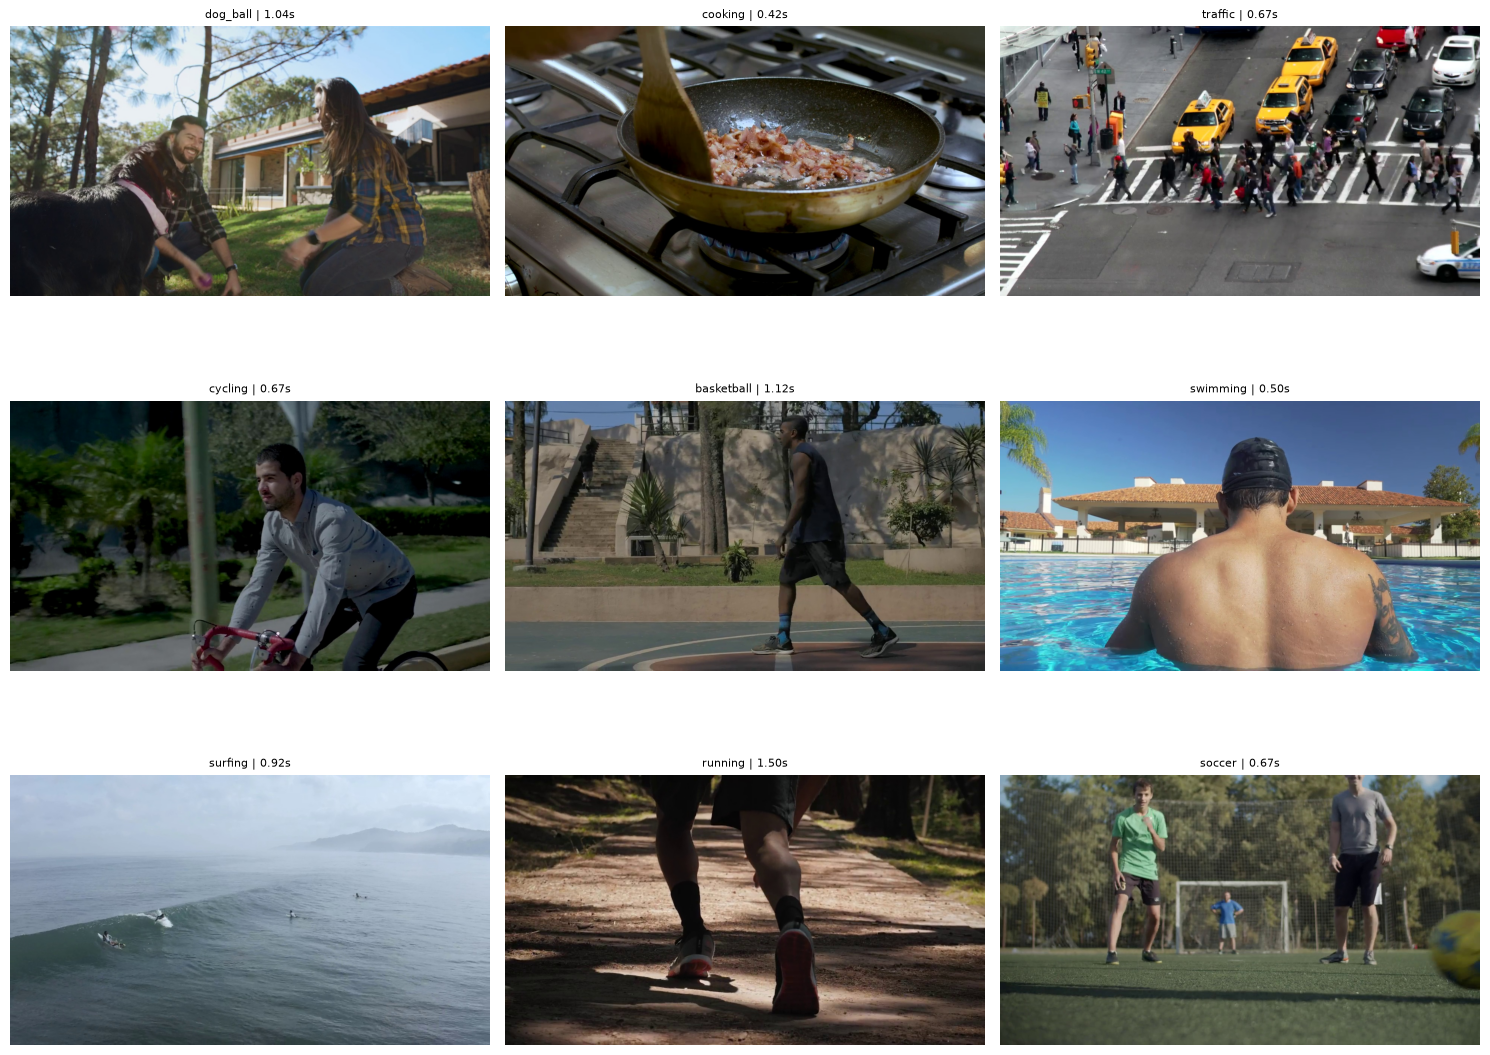

In [14]:
figure, axes = plt.subplots(3, 3, figsize=(15, 12))
for axis, (_, record) in zip(axes.ravel(), representative_df.iterrows()):
    frame_path = Path(record['frame_path'])

    with Image.open(frame_path) as source_image:
        frame_image = source_image.convert('RGB').copy()

    axis.imshow(frame_image)
    axis.set_title(
        f"{record['video_id']} | {float(record['timestamp_sec']):.2f}s",
        fontsize=8,
    )
    axis.axis('off')

figure.tight_layout()
plt.show()
